In [29]:
import numpy as np
import cv2
import os
import pandas as pd
from PIL import Image
import h5py
import matplotlib.pyplot as plt
from scipy import io
from time import time
import sys
from sklearn.model_selection import train_test_split
from helper_functions.data import write_h5, read_h5_numpy
from typing import List

print(os.getcwd())

n_scale = 6

/Users/matte/Dropbox/RESEARCH/PyTorch-Lightning-template/notebooks


In [30]:
def resize_images(
        X : np.ndarray,
        new_dims : List
        ) -> np.ndarray:

    X_resize = np.zeros((
        X.shape[0],
        new_dims[0],
        new_dims[1]),
        np.uint8)

    print('Resizing images ...')
    for i in range(X.shape[0]):
        if i/10000 == i//10000:
            print('   -> Step {} of {}'.format(i,X.shape[0]))
        x = X[i,...]
        if n_scale > 1:
            x = cv2.resize(
                x.astype(np.uint8), 
                dsize=(n_scale*28,n_scale*28), 
                interpolation=cv2.INTER_CUBIC
                )
        X_resize[i,...] = x

    print('Done resizing!')

    return X_resize

In [31]:
fileload = r'../data/fashion-mnist/fashion-mnist_train.csv'

data = pd.read_csv(fileload, low_memory=False).to_numpy()
X,y = data[:,1:], data[:,0].reshape(-1,1)
dims = X.shape
dims = [int(x) for x in [dims[0], np.sqrt(dims[1]), np.sqrt(dims[1])]]
X = X.reshape(dims).astype(np.uint8)

new_dims = [n_scale*X.shape[1], n_scale*X.shape[2]]

X_resize = resize_images(X, new_dims)

###
X_train, X_val, y_train, y_val = train_test_split(
    X_resize,y,
    test_size=.15,
    shuffle=True,
    random_state=42
)

dict_train = {
    'X' : X_train,
    'y' : y_train,
}

dict_val = {
    'X' : X_val,
    'y' : y_val,
}

verbose = True

write_h5(
    data = dict_train,
    filename='../data/fashion-mnist/fashion-mnist_{}x{}_train'.format(n_scale*28,n_scale*28),
    dtype=np.uint8,
    verbose = verbose
    )

write_h5(
    data = dict_val,
    filename='../data/fashion-mnist/fashion-mnist_{}x{}_val'.format(n_scale*28,n_scale*28),
    dtype=np.uint8,
    verbose = verbose
    )

Resizing images ...
   -> Step 0 of 60000
   -> Step 10000 of 60000
   -> Step 20000 of 60000
   -> Step 30000 of 60000
   -> Step 40000 of 60000
   -> Step 50000 of 60000
Done resizing!
Processing key: X, dims: (51000, 168, 168), size: 1439.42MB
Processing key: y, dims: (51000, 1), size: 0.41MB
 -> DonE! Elapsed time: 5.351s, final size: 746.35MB
Processing key: X, dims: (9000, 168, 168), size: 254.02MB
Processing key: y, dims: (9000, 1), size: 0.07MB
 -> DonE! Elapsed time: 0.923s, final size: 132.53MB


In [32]:
fileload = r'../data/fashion-mnist/fashion-mnist_test.csv'

data = pd.read_csv(fileload, low_memory=False).to_numpy()
X,y = data[:,1:], data[:,0].reshape(-1,1)
dims = X.shape
dims = [int(x) for x in [dims[0], np.sqrt(dims[1]), np.sqrt(dims[1])]]
X = X.reshape(dims)

X_resize = resize_images(X, new_dims)

###
dict_test = {
    'X' : X_resize,
    'y' : y,
}

verbose = True

write_h5(
    data = dict_test,
    filename='../data/fashion-mnist/fashion-mnist_{}x{}_test'.format(n_scale*28,n_scale*28),
    dtype=np.int8,
    verbose = verbose
    )



Resizing images ...
   -> Step 0 of 10000
Done resizing!
Processing key: X, dims: (10000, 168, 168), size: 282.24MB
Processing key: y, dims: (10000, 1), size: 0.00MB
 -> DonE! Elapsed time: 0.842s, final size: 78.62MB


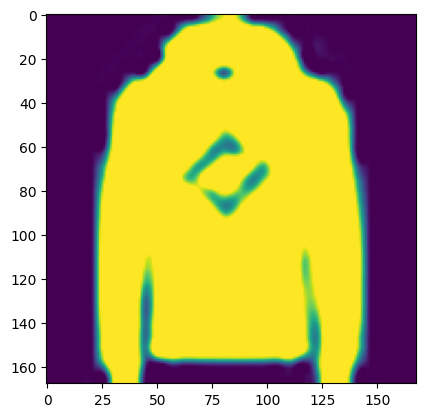

[2]


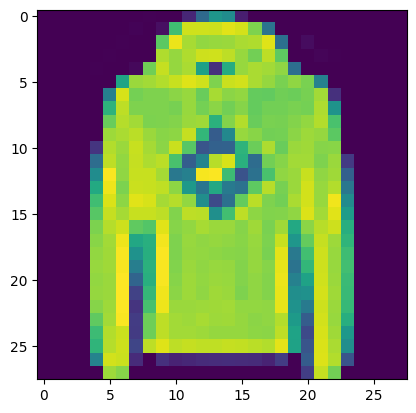

In [33]:
data_load = read_h5_numpy(
    '../data/fashion-mnist/fashion-mnist_{}x{}_test.h5'.format(new_dims[0],new_dims[1])
)

ind = 1000
# ind = 1001

plt.imshow(data_load['X'][ind,:,:])
plt.show()

paths_load = [
    r'../data/fashion-mnist/fashion-mnist_train.csv',
    r'../data/fashion-mnist/fashion-mnist_test.csv'
    ]

data = pd.read_csv(paths_load[1], low_memory=False).to_numpy()
X,y = data[:,1:], data[:,0].reshape(-1,1)
dims = X.shape
dims = [int(x) for x in [dims[0], np.sqrt(dims[1]), np.sqrt(dims[1])]]
X = X.reshape(dims)
print(y[ind])

plt.imshow(X[ind,:,:])
plt.show()